# Correlation between on-target efficiency and LFC  
Using CRISPick or DeepSpCas9 or CRISPRon  
sgRNAs with on-target scores: NGG PAM, exon only (except for CRISPRon)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import ks_2samp
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import matplotlib as mpl
from matplotlib import font_manager

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'
from scipy.stats import pearsonr
from scipy.stats import spearmanr

In [2]:
id_prefix_list = [
	"MYC_GFP_"
]

In [3]:
def on_target_corr(
		gene, myc_var, treatment_col,
		date,
		test_name,
		baseline,
		treatments,
		day_numbers,
		merge_method_replicate, 
		pred_method,
		sgRNA_seq_col,
		score_col,
		region_filter,
		per_time_unit=True):
	
	# merge 4 replicates per sgRNA
	df_lfc = None
	for treatment in treatments:
		df_lfc_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{test_name}/MYC_U1.{treatment}_vs_{baseline}.sgrna_summary.txt"
		df_lfc_rep = pd.read_csv(df_lfc_path, sep="\t", usecols=["sgrna", "LFC"])
		df_lfc_rep = df_lfc_rep.rename(columns={"LFC": f"LFC_{treatment}"})
		if df_lfc is None:
			df_lfc = df_lfc_rep
		else:
			# Merge on 'sgrna'
			df_lfc = pd.merge(df_lfc, df_lfc_rep, on="sgrna", how="inner")
	print(len(df_lfc))

	treatment_lfc_columns = [f"LFC_{treatment}" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_columns, day_numbers):
			df_lfc[col] = df_lfc[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df_lfc["per time unit LFC"] = df_lfc[treatment_lfc_columns].mean(axis=1)

	# load the lib and pred score
	lib_path = f"/media/scratch/fy2306/projects/base_editing/data/grna_type/MYC-lib-for-mageck.type.{myc_var}.organized.txt"
	df_lib = pd.read_csv(lib_path, sep="\t", usecols=["id", "grna_target_seq_rc", "indel_base_pos_chr", "indel_repeats"])
	df_lib = df_lib[df_lib["indel_repeats"] == False]
	if pred_method == "CRISPRon":
		pred_path = f"/media/scratch/fy2306/projects/base_editing/data/sgRNA_on_target/{pred_method}_MYC.csv"
		if region_filter != "exon-2" and region_filter != "no":
			df_pred = pd.read_csv(pred_path, sep=",", usecols=[sgRNA_seq_col, score_col, "cut-site"], comment="#")
			df_pred[sgRNA_seq_col] = df_pred[sgRNA_seq_col].str[:-3]	# remove PAM
			df_pred = df_pred[df_pred['cut-site'].str.contains(region_filter, na=False)]
		else:
			df_pred = pd.read_csv(pred_path, sep=",", usecols=[sgRNA_seq_col, score_col], comment="#")
			df_pred[sgRNA_seq_col] = df_pred[sgRNA_seq_col].str[:-3]	# remove PAM
	else:
		pred_path = f"/media/scratch/fy2306/projects/base_editing/data/sgRNA_on_target/{pred_method}_MYC.txt"
		df_pred = pd.read_csv(pred_path, sep="\t", usecols=[sgRNA_seq_col, score_col])
	df_pred = df_pred[[sgRNA_seq_col, score_col]]
	df_pred[score_col] = df_pred[score_col].astype(float)
	print(len(df_pred))
	df_pred = pd.merge(df_pred, df_lib, left_on=sgRNA_seq_col, right_on="grna_target_seq_rc", how="inner")
	if region_filter == "MYC:CDS" or region_filter == "exon-2":	# further filter for exon-2
		df_pred = df_pred[(df_pred["indel_base_pos_chr"] >= 127738263) & (df_pred["indel_base_pos_chr"] <= 127739019)]	# ENST00000377970.6
	print(len(df_pred))
	merged_df = pd.merge(df_lfc, df_pred, left_on="sgrna", right_on="id", how="inner")
	print(len(merged_df))

	# corr

	r_p, _ = pearsonr(merged_df["per time unit LFC"], merged_df[score_col])
	r_s, _ = spearmanr(merged_df["per time unit LFC"], merged_df[score_col])

	fig, ax = plt.subplots(figsize=(4, 4))

	hb = ax.scatter(
		x=merged_df["per time unit LFC"],
		y=merged_df[score_col],
		c='#AA66FF',       
		alpha=0.6,      
		s=5            
	)

	sns.despine(ax=ax, top=True, right=True)
	ax.set_xlim(merged_df["per time unit LFC"].min() - 0.02, merged_df["per time unit LFC"].max() + 0.02)
	ax.set_ylim(merged_df[score_col].min() - 1, merged_df[score_col].max() + 1)
	ax.set_xlabel("sgRNA phenotype score", fontsize=13)
	ax.set_ylabel("Predicted sgRNA efficiency", fontsize=13)
	ax.set_title(pred_method, fontsize=13)
	ax.tick_params(labelsize=12)

	ax.text(
		0.05, 0.15,
		f"Pearson r = {r_p:.2f} \nSpearman r = {r_s:.2f}",
		transform=ax.transAxes,
		fontsize=12,
		verticalalignment='top',
		horizontalalignment='left'
	)

	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)

	plt.tight_layout()
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/screening/sgRNA_on_target.{pred_method}.corr.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

	# cdf

	sorted_df = merged_df.sort_values(by=score_col, ascending=True).reset_index(drop=True)

	midpoint = len(sorted_df) // 2
	group1 = sorted_df.iloc[:midpoint]   # Lower half
	group2 = sorted_df.iloc[midpoint:]   # Upper half

	def compute_cdf(values):
		values_sorted = np.sort(values)
		cdf = np.arange(1, len(values_sorted)+1) / len(values_sorted)
		return values_sorted, cdf

	x1, cdf1 = compute_cdf(group1["per time unit LFC"])
	x2, cdf2 = compute_cdf(group2["per time unit LFC"])

	group_low = group1["per time unit LFC"]
	median_low = group_low.median()
	group_high = group2["per time unit LFC"]
	median_high = group_high.median()
	ks_stat, p_value = ks_2samp(group_low, group_high)

	shift = abs(median_high - median_low)

	# Step 4: Plot
	plt.figure(figsize=(4, 4))
	plt.plot(x1, cdf1, label='Lower 50% of on-target score', color="#66CCFE")
	plt.plot(x2, cdf2, label='Upper 50% of on-target score', color="#FF0066")
	plt.xlabel("sgRNA phenotype score", fontsize=13)
	plt.ylabel("CDF", fontsize=13)
	plt.title(f"{pred_method}", fontsize=13)
	mant, exp = f"{p_value:.2e}".split("e")
	mant = float(mant); exp = int(exp)
	handles = [
		Line2D([], [], linestyle="None", marker=None, color="#FF0066",
			label=f'High efficiency (N={len(group2):,})'),
		Line2D([], [], linestyle="None", marker=None, color="#66CCFE",
			label=f'Other (N={len(group1):,})'),
		Line2D([], [], linestyle="None", marker=None, color="black",
			label=rf"$P={mant:.2f}\times 10^{{{exp}}}$"),
	]
	plt.legend(handles=handles, loc="upper left", frameon=False, fontsize=13,
			handlelength=0, handletextpad=0, labelcolor="linecolor")
	plt.yticks([0, 0.5, 1], fontsize=12)
	xmin = sorted_df["per time unit LFC"].quantile(0.03)
	xmax = sorted_df["per time unit LFC"].quantile(0.97)
	plt.xlim(xmin, xmax)
	plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(0.1))
	plt.xticks(fontsize=12)
	plt.gca().spines['top'].set_visible(False)
	plt.gca().spines['right'].set_visible(False)
	plt.grid(False)
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/screening/sgRNA_on_target.{pred_method}.cdf.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

24000
199
127
127


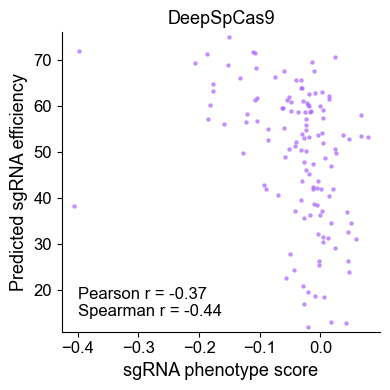

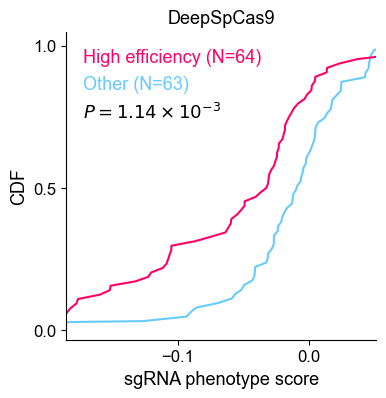

24000
222
140
140


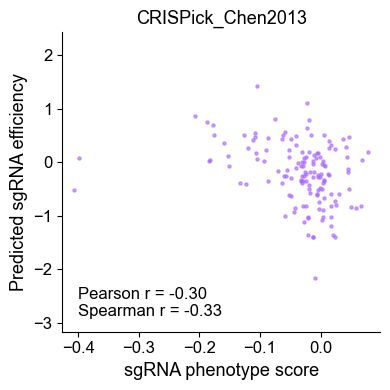

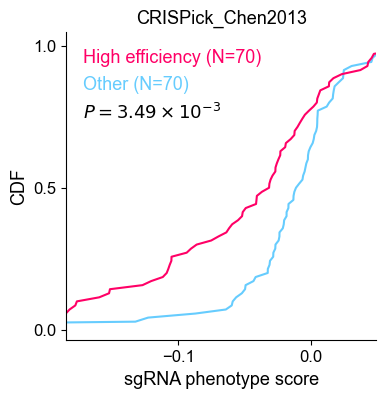

24000
222
140
140


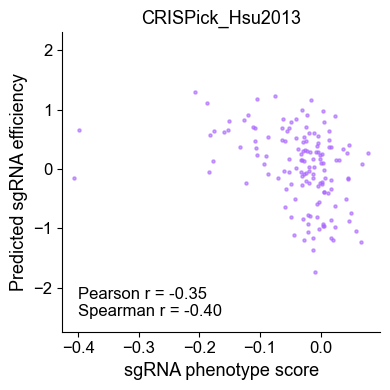

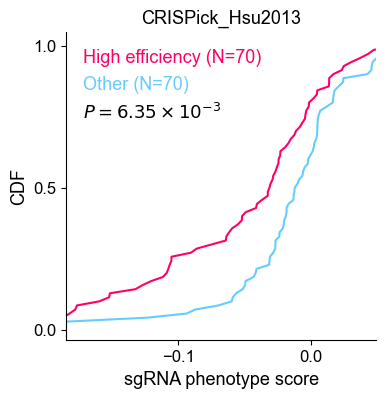

24000
1578
140
140


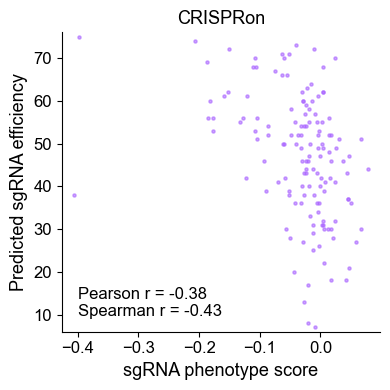

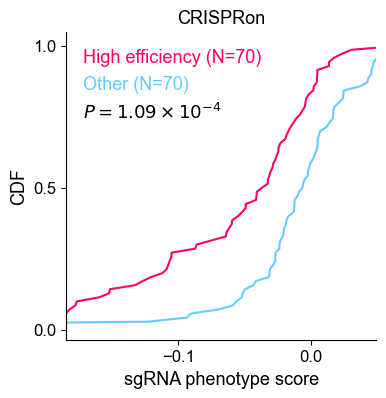

In [6]:
gene = "MYC-wt"
myc_var = "myc2_indel"
treatment_col = "indel"
date = "20250416"
test_name = "test-1-standard/test"
baseline = "Cas9-HMOI_D0"
treatments = ["Cas9-LMOI_D20", "Cas9-LMOI_D8", "Cas9_SpRY_L_MOI_D_20", "Cas9_SpRY_L_MOI_D_8"]
day_numbers = [20, 8, 20, 8]
merge_method_replicate = "mean"
# DeepSpCas9
pred_method = "DeepSpCas9"
sgRNA_seq_col = "Guide Sequence (20bp)"
score_col = "DeepSpCas9 Score"
region_filter = "exon-2"
on_target_corr(
		gene, myc_var, treatment_col,
		date,
		test_name,
		baseline,
		treatments,
		day_numbers,
		merge_method_replicate, 
		pred_method,
		sgRNA_seq_col,
		score_col,
		region_filter,
		per_time_unit=True)
# CRISPick
pred_method = "CRISPick_Chen2013"
sgRNA_seq_col = "sgRNA Sequence"
score_col = "On-Target Efficacy Score"
on_target_corr(
		gene, myc_var, treatment_col,
		date,
		test_name,
		baseline,
		treatments,
		day_numbers,
		merge_method_replicate, 
		pred_method,
		sgRNA_seq_col,
		score_col,
		region_filter,
		per_time_unit=True)
pred_method = "CRISPick_Hsu2013"
sgRNA_seq_col = "sgRNA Sequence"
score_col = "On-Target Efficacy Score"
on_target_corr(
		gene, myc_var, treatment_col,
		date,
		test_name,
		baseline,
		treatments,
		day_numbers,
		merge_method_replicate, 
		pred_method,
		sgRNA_seq_col,
		score_col,
		region_filter,
		per_time_unit=True)
# CRISPRon
pred_method = "CRISPRon"
sgRNA_seq_col = "target+PAM"
score_col = "Eff.(%)"
on_target_corr(
		gene, myc_var, treatment_col,
		date,
		test_name,
		baseline,
		treatments,
		day_numbers,
		merge_method_replicate, 
		pred_method,
		sgRNA_seq_col,
		score_col,
		region_filter,
		per_time_unit=True)